# 04 — Final Detector Evaluation and Operating-Point Selection

## Number Plate Detection of Vehicles

This notebook performs the final detector evaluation required by the project.

### Coverage
- Restore the frozen project from Google Drive
- Verify the frozen 115-image dataset
- Load `models/best.pt`
- Reconfirm validation and untouched test performance
- Sweep confidence thresholds
- Match predictions to ground truth using IoU
- Report TP, FP, FN, Precision, Recall, F1
- Select the operating confidence threshold
- Plot Precision / Recall / F1 vs confidence
- Inspect false positives and false negatives
- Reconfirm YOLO inference time
- Export final detector reports

> No retraining is performed in this notebook.

## 1. Colab Setup


**Use case:** Prepare the Colab runtime, install the detector-evaluation dependencies, mount Google Drive, and confirm GPU availability before final evaluation.


In [ ]:
# ============================================================
# 1. COLAB SETUP
# ============================================================

# Install the libraries required for final YOLO detector evaluation.
!python -m pip install -q ultralytics "pandas==2.2.3" pyyaml opencv-python-headless

from google.colab import drive
drive.mount("/content/drive")  # Access frozen project files and save final reports

from pathlib import Path       # File and folder path handling
from zipfile import ZipFile   # Extract project ZIP files
import shutil                  # Copy/remove files and folders
import time                    # Runtime measurement
import math                    # Grid/row calculations for visualizations

import cv2                     # Read images and draw detection boxes
import numpy as np             # Numerical and bounding-box calculations
import pandas as pd            # Store and analyze evaluation results
import matplotlib.pyplot as plt  # Plot detector results and error examples

import torch                   # GPU/CUDA detection
from ultralytics import YOLO   # Load and evaluate the YOLO detector
from IPython.display import display  # Display DataFrames cleanly

print("CUDA:", torch.cuda.is_available())  # Check GPU availability

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))  # Show active GPU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.5 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
CUDA: True
GPU: Tesla T4


### Setup Result

**Result:** ✅ Colab setup completed with CUDA enabled.

- **CUDA available:** True
- **GPU:** Tesla T4
- Google Drive mounted successfully.

**Interpretation:**  
The final detector evaluation is running in a GPU-enabled Colab environment, so later YOLO validation and speed measurements can use the Tesla T4 consistently.


## 2. Restore Frozen Project


**Use case:** Restore the frozen project snapshot from Google Drive into a clean Colab working directory and define the dataset, model, and report paths.


In [ ]:
# ============================================================
# 2. RESTORE FROZEN PROJECT
# ============================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")  # Google Drive root
PROJECT_DIR = Path("/content/number_plate_training")  # Clean Colab project folder
TEMP_DIR = Path("/content/_detector_eval_extract")  # Temporary ZIP extraction folder

zip_candidates = [
    DRIVE_ROOT / "number_plate_training.zip",
    DRIVE_ROOT / "Number-Plate-Detection-Final.zip",
]  # Expected frozen project ZIP names

ZIP_PATH = next(
    (p for p in zip_candidates if p.exists()),
    None
)  # Use the first expected ZIP found

if ZIP_PATH is None:
    matches = list(
        DRIVE_ROOT.rglob("*number*plate*.zip")
    )  # Fallback recursive ZIP search

    ZIP_PATH = (
        matches[0]
        if matches
        else None
    )

assert (
    ZIP_PATH is not None
    and ZIP_PATH.exists()
), "Project ZIP not found."  # Stop if frozen project archive is unavailable

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)  # Remove old runtime project copy

if TEMP_DIR.exists():
    shutil.rmtree(TEMP_DIR)  # Remove previous temporary extraction

TEMP_DIR.mkdir(
    parents=True,
    exist_ok=True
)  # Create clean extraction folder

with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(TEMP_DIR)  # Extract frozen project archive

EXTRACTED_ROOT = None

for candidate in [
    TEMP_DIR / "number_plate_training",
    TEMP_DIR / "Number-Plate-Detection-Final",
    TEMP_DIR
]:
    if (
        candidate
        / "data"
        / "processed"
    ).exists():
        EXTRACTED_ROOT = candidate
        break  # Select the folder containing the frozen dataset

assert (
    EXTRACTED_ROOT is not None
), "Could not find data/processed."  # Confirm valid extracted project structure

shutil.copytree(
    EXTRACTED_ROOT,
    PROJECT_DIR
)  # Copy frozen project into clean Colab workspace

shutil.rmtree(
    TEMP_DIR
)  # Remove temporary extracted files

DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)  # Frozen processed dataset

MODEL_PATH = (
    PROJECT_DIR
    / "models"
    / "best.pt"
)  # Final selected YOLO checkpoint

REPORT_DIR = (
    PROJECT_DIR
    / "reports"
    / "detection_operating_point"
)  # Final detector evaluation reports

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

assert DATA_DIR.exists()  # Confirm frozen dataset exists
assert MODEL_PATH.exists()  # Confirm final YOLO model exists

print("Project:", PROJECT_DIR)
print("Model:", MODEL_PATH)

Project: /content/number_plate_training
Model: /content/number_plate_training/models/best.pt


### Project Restore Result

**Result:** ✅ Frozen project and final detector checkpoint were restored successfully.

- **Project:** `/content/number_plate_training`
- **Model:** `/content/number_plate_training/models/best.pt`

**Interpretation:**  
The evaluation notebook is using the saved project snapshot and the previously selected `best.pt`; no retraining or replacement model is introduced here.


## 3. Verify Frozen Dataset


**Use case:** Confirm that final evaluation uses the unchanged 115-image / 233-box dataset with the expected 90/13/12 train-validation-test split.


In [ ]:
# ============================================================
# 3. VERIFY FROZEN DATASET
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}  # Supported image formats
rows = []  # Store split-wise dataset counts

for split in ["train", "val", "test"]:
    image_dir = DATA_DIR / split / "images"  # Current split image folder
    label_dir = DATA_DIR / split / "labels"  # Current split label folder

    images = [p for p in image_dir.iterdir()
              if p.is_file() and p.suffix.lower() in IMAGE_EXTS]  # Count valid images
    labels = list(label_dir.glob("*.txt"))  # Collect YOLO label files
    boxes = sum(sum(1 for line in lp.read_text().splitlines() if line.strip())
                for lp in labels)  # Count annotated boxes

    rows.append({
        "split": split,
        "images": len(images),
        "label_files": len(labels),
        "boxes": boxes,
    })  # Store split summary

dataset_check = pd.DataFrame(rows)  # Convert summary to DataFrame
display(dataset_check)

assert dataset_check["images"].sum() == 115  # Confirm total images
assert dataset_check["boxes"].sum() == 233  # Confirm total boxes
assert dataset_check.set_index("split").loc["train", "images"] == 90  # Train split
assert dataset_check.set_index("split").loc["val", "images"] == 13  # Validation split
assert dataset_check.set_index("split").loc["test", "images"] == 12  # Test split

print("✅ Frozen dataset verified")

,split,images,label_files,boxes
0,train,90,90,185
1,val,13,13,23
2,test,12,12,25


✅ Frozen dataset verified


### Frozen Dataset Verification Result

| Split | Images | Label Files | Boxes |
|---|---:|---:|---:|
| Train | 90 | 90 | 185 |
| Validation | 13 | 13 | 23 |
| Test | 12 | 12 | 25 |
| **Total** | **115** | **115** | **233** |

**Result:** ✅ The frozen dataset matches the expected project dataset.

**Interpretation:**  
Final detector evaluation uses the same 115 images and 233 annotated plate boxes. The validation and test sets remain fixed at 13 and 12 images respectively.


## 4. Load Final YOLO Model


**Use case:** Load the final selected YOLO checkpoint and choose GPU when available so every later detector evaluation uses the same frozen model.


In [ ]:
# ============================================================
# 4. LOAD FINAL YOLO MODEL
# ============================================================

model = YOLO(str(MODEL_PATH))  # Load the frozen final YOLO checkpoint
DEVICE = 0 if torch.cuda.is_available() else "cpu"  # Use GPU if available
print("Model loaded:", MODEL_PATH)
print("Device:", DEVICE)

Model loaded: /content/number_plate_training/models/best.pt
Device: 0


### Final Model Load Result

**Result:** ✅ The selected YOLO detector loaded successfully from `models/best.pt`.

- **Execution device:** GPU index `0`

**Interpretation:**  
All subsequent metrics, confidence-threshold analysis, error inspection, and speed verification are based on the same frozen final detector.


## 5. Reconfirm Validation and Untouched Test Metrics

mAP is reported separately from the confidence operating-point analysis.


**Use case:** Reconfirm standard Ultralytics validation and untouched-test detector metrics before operating-point analysis.


In [ ]:
# ============================================================
# 5. YOLO VALIDATION + TEST METRICS
# ============================================================

import yaml  # Create YOLO evaluation configuration

DATA_YAML = PROJECT_DIR / "configs" / "final_eval_data.yaml"
DATA_YAML.parent.mkdir(parents=True, exist_ok=True)  # Ensure config folder exists

data_config = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {
        0: "Number Plate"
    }
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(
        data_config,
        f,
        sort_keys=False
    )  # Save YOLO dataset configuration

print("Evaluation YAML:", DATA_YAML)
print(DATA_YAML.read_text())


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

val_metrics = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=832,
    device=DEVICE,
    verbose=False,
)  # Evaluate on validation split


# ------------------------------------------------------------
# UNTOUCHED TEST
# ------------------------------------------------------------

test_metrics = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=832,
    device=DEVICE,
    verbose=False,
)  # Evaluate on untouched test split


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

detector_metrics = pd.DataFrame([
    {
        "split": "validation",
        "precision": float(val_metrics.box.mp),
        "recall": float(val_metrics.box.mr),
        "mAP50": float(val_metrics.box.map50),
        "mAP50_95": float(val_metrics.box.map),
    },
    {
        "split": "test",
        "precision": float(test_metrics.box.mp),
        "recall": float(test_metrics.box.mr),
        "mAP50": float(test_metrics.box.map50),
        "mAP50_95": float(test_metrics.box.map),
    },
])  # Store validation and test metrics together

display(
    detector_metrics.style.format({
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "mAP50": "{:.2%}",
        "mAP50_95": "{:.2%}",
    })
)

detector_metrics.to_csv(
    REPORT_DIR / "detector_validation_test_metrics.csv",
    index=False
)  # Save final detector metrics

print("✅ Validation and untouched test evaluation complete.")

Evaluation YAML: /content/number_plate_training/configs/final_eval_data.yaml
path: /content/number_plate_training/data/processed
train: train/images
val: val/images
test: test/images
names:
  0: Number Plate

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2402.6±1795.0 MB/s, size: 1914.8 KB)
val: Scanning /content/number_plate_training/data/processed/val/labels... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 60.1it/s 0.2s
val: New cache created: /content/number_plate_training/data/processed/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5s/it 2.5s
                   all         13         23      0.991       0.87      0.963      0.522
Speed: 0.6ms preprocess, 15.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val-2
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-

,split,precision,recall,mAP50,mAP50_95
0,validation,99.11%,86.96%,96.35%,52.16%
1,test,93.05%,60.00%,68.62%,38.32%


✅ Validation and untouched test evaluation complete.


### Validation and Test Metric Result

| Split | Precision | Recall | mAP@50 | mAP@50-95 |
|---|---:|---:|---:|---:|
| Validation | **99.11%** | **86.96%** | **96.35%** | **52.16%** |
| Untouched Test | **93.05%** | **60.00%** | **68.62%** | **38.32%** |

**Result:** ✅ Validation and untouched-test evaluation completed successfully.

**Interpretation:**  
The detector performs very strongly on validation, especially at mAP@50, but performance drops on unseen test data—most noticeably recall and mAP. The final report therefore keeps validation and test performance separate rather than presenting the stronger validation result as general test performance.


## 6. Ground-Truth and IoU Utilities


**Use case:** Provide ground-truth conversion, IoU calculation, and one-to-one prediction matching utilities required for TP/FP/FN analysis.


In [ ]:
# ============================================================
# 6. GROUND-TRUTH AND IOU UTILITIES
# ============================================================

def load_yolo_ground_truth(image_path, label_dir):
    image = cv2.imread(str(image_path))  # Load image to get original dimensions
    if image is None:
        raise FileNotFoundError(image_path)

    h, w = image.shape[:2]  # Image height and width
    label_path = label_dir / f"{image_path.stem}.txt"  # Matching YOLO label file
    boxes = []

    if not label_path.exists():
        return boxes  # No annotation file means no GT boxes

    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue

        parts = line.split()
        cls_id = int(float(parts[0]))  # YOLO class ID
        xc, yc, bw, bh = map(float, parts[1:5])  # Normalized YOLO coordinates

        x1 = (xc - bw / 2) * w  # Convert to pixel-space corners
        y1 = (yc - bh / 2) * h
        x2 = (xc + bw / 2) * w
        y2 = (yc + bh / 2) * h

        boxes.append({
            "class_id": cls_id,
            "xyxy": np.array([x1, y1, x2, y2], dtype=float)
        })

    return boxes

def box_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)  # Intersection coordinates
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)  # Intersection width
    ih = max(0.0, iy2 - iy1)  # Intersection height

    inter = iw * ih  # Intersection area
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = area_a + area_b - inter  # Combined unique area

    return inter / union if union > 0 else 0.0  # IoU score

def match_predictions_to_gt(gt_boxes, pred_boxes, iou_threshold=0.50):
    gt_used, pred_used, matches = set(), set(), []
    candidates = []

    for pi, pred in enumerate(pred_boxes):
        for gi, gt in enumerate(gt_boxes):
            iou = box_iou(pred["xyxy"], gt["xyxy"])  # Compare prediction with GT
            if iou >= iou_threshold:
                candidates.append((iou, pi, gi))

    candidates.sort(reverse=True, key=lambda x: x[0])  # Highest-IoU matches first

    for iou, pi, gi in candidates:
        if pi in pred_used or gi in gt_used:
            continue  # Prevent duplicate matching
        pred_used.add(pi)
        gt_used.add(gi)
        matches.append((pi, gi, iou))

    return {
        "tp": len(matches),
        "fp": len(pred_boxes) - len(matches),
        "fn": len(gt_boxes) - len(matches),
        "matches": matches,
        "matched_pred_indices": pred_used,
        "matched_gt_indices": gt_used,
    }

### Ground-Truth / IoU Utility Result

**Result:** ✅ Ground-truth conversion, IoU calculation, and one-to-one matching utilities are defined.

**Interpretation:**  
These functions establish a consistent IoU ≥ 0.50 rule for later TP, FP, and FN counting. Because this cell only defines reusable functions, no numerical output is expected.


## 7. Cache Low-Confidence Validation and Test Predictions


**Use case:** Cache low-confidence predictions for both validation and test so confidence thresholds can be evaluated repeatedly without rerunning YOLO for every threshold.


In [ ]:
# ============================================================
# 7. CACHE LOW-CONFIDENCE PREDICTIONS
# ============================================================

VAL_IMG_DIR = DATA_DIR / "val" / "images"  # Validation images
VAL_LABEL_DIR = DATA_DIR / "val" / "labels"  # Validation labels

TEST_IMG_DIR = DATA_DIR / "test" / "images"  # Test images
TEST_LABEL_DIR = DATA_DIR / "test" / "labels"  # Test labels

def image_list(image_dir):
    return sorted([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])  # Return valid images in fixed order

val_images = image_list(VAL_IMG_DIR)  # Validation image list
test_images = image_list(TEST_IMG_DIR)  # Test image list

def build_prediction_cache(image_paths, label_dir, split_name):
    cache = {}  # Store GT and predictions for each image

    for idx, image_path in enumerate(image_paths, start=1):
        image = cv2.imread(str(image_path))  # Load image

        if image is None:
            continue

        result = model.predict(
            source=image,
            conf=0.01,
            iou=0.70,
            imgsz=832,
            device=DEVICE,
            verbose=False,
        )[0]  # Run low-confidence YOLO prediction

        preds = []

        if result.boxes is not None:
            for box in result.boxes:
                preds.append({
                    "confidence": float(box.conf[0].cpu()),  # Detection confidence
                    "xyxy": box.xyxy[0].cpu().numpy().astype(float),  # Bounding box
                })

        cache[image_path.name] = {
            "image_path": image_path,
            "gt_boxes": load_yolo_ground_truth(
                image_path,
                label_dir
            ),  # Ground-truth boxes
            "predictions": preds,  # Cached predictions
        }

        print(
            f"[{split_name} {idx:02d}/{len(image_paths):02d}] "
            f"{image_path.name} | "
            f"GT={len(cache[image_path.name]['gt_boxes'])} | "
            f"Pred@0.01={len(preds)}"
        )

    return cache

print("Caching validation predictions...")
val_prediction_cache = build_prediction_cache(
    val_images,
    VAL_LABEL_DIR,
    "VAL"
)

print()
print("Caching test predictions...")
test_prediction_cache = build_prediction_cache(
    test_images,
    TEST_LABEL_DIR,
    "TEST"
)

print()
print("✅ Validation images cached:", len(val_prediction_cache))
print("✅ Test images cached      :", len(test_prediction_cache))

Caching validation predictions...
[VAL 01/13] 20230614_150823ll.jpg | GT=1 | Pred@0.01=5
[VAL 02/13] 20230614_150932ll.jpg | GT=3 | Pred@0.01=18
[VAL 03/13] 20230614_150959ll.jpg | GT=1 | Pred@0.01=8
[VAL 04/13] 20230620_160047ll.jpg | GT=3 | Pred@0.01=22
[VAL 05/13] 20230620_160054ll.jpg | GT=1 | Pred@0.01=8
[VAL 06/13] 20230620_160109ll.jpg | GT=3 | Pred@0.01=16
[VAL 07/13] 20230620_160150ll.jpg | GT=2 | Pred@0.01=15
[VAL 08/13] 20230620_160222ll.jpg | GT=4 | Pred@0.01=33
[VAL 09/13] 20230620_160338ll.jpg | GT=1 | Pred@0.01=9
[VAL 10/13] 20230620_160513ll.jpg | GT=1 | Pred@0.01=12
[VAL 11/13] 20230620_160530ll.jpg | GT=1 | Pred@0.01=2
[VAL 12/13] 20230620_161015ll.jpg | GT=1 | Pred@0.01=4
[VAL 13/13] 20230620_161149ll.jpg | GT=1 | Pred@0.01=5

Caching test predictions...
[TEST 01/12] 20230614_151238ll.jpg | GT=1 | Pred@0.01=5
[TEST 02/12] 20230614_151246ll.jpg | GT=1 | Pred@0.01=5
[TEST 03/12] 20230620_160118ll.jpg | GT=2 | Pred@0.01=8
[TEST 04/12] 20230620_160204ll.jpg | GT=2 | Pred

### Prediction Cache Result

- **Validation images cached:** 13/13
- **Test images cached:** 12/12
- Predictions were retained from a low **0.01 confidence** inference pass.

**Result:** ✅ Both frozen evaluation splits were cached successfully.

**Interpretation:**  
The threshold sweep can now evaluate many confidence cutoffs against the exact same cached predictions, while the test cache remains unused for threshold selection until the validation operating point is frozen.


## 8. Confidence-Threshold Sweep — Validation Only


**Use case:** Evaluate a range of confidence thresholds on the validation split only and measure TP, FP, FN, precision, recall, F1, and matched IoU.


In [ ]:
# ============================================================
# 8. CONFIDENCE THRESHOLD SWEEP — VALIDATION ONLY
# ============================================================

THRESHOLDS = [
    0.05, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75,
    0.80, 0.85, 0.90
]  # Confidence values to test

IOU_MATCH_THRESHOLD = 0.50  # Minimum IoU for a correct detection

def evaluate_cache_at_threshold(cache, conf_threshold):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    matched_ious = []

    for item in cache.values():

        preds = [
            p for p in item["predictions"]
            if p["confidence"] >= conf_threshold
        ]  # Keep predictions above current confidence

        match = match_predictions_to_gt(
            item["gt_boxes"],
            preds,
            iou_threshold=IOU_MATCH_THRESHOLD
        )  # Match predictions with ground truth

        total_tp += match["tp"]
        total_fp += match["fp"]
        total_fn += match["fn"]

        matched_ious.extend([
            m[2] for m in match["matches"]
        ])  # Store IoUs of successful matches

    precision = (
        total_tp / (total_tp + total_fp)
        if (total_tp + total_fp) > 0
        else 0.0
    )

    recall = (
        total_tp / (total_tp + total_fn)
        if (total_tp + total_fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_matched_iou": (
            float(np.mean(matched_ious))
            if matched_ious else np.nan
        ),
    }

threshold_rows = []

for conf_threshold in THRESHOLDS:
    metrics = evaluate_cache_at_threshold(
        val_prediction_cache,
        conf_threshold
    )  # Evaluate validation cache at this threshold

    threshold_rows.append({
        "confidence_threshold": conf_threshold,
        **metrics,
    })

threshold_df = pd.DataFrame(threshold_rows)  # Build threshold comparison table

display(
    threshold_df.style.format({
        "confidence_threshold": "{:.2f}",
        "precision": "{:.2%}",
        "recall": "{:.2%}",
        "f1": "{:.2%}",
        "mean_matched_iou": "{:.3f}",
    })
)

threshold_df.to_csv(
    REPORT_DIR / "validation_confidence_threshold_sweep.csv",
    index=False
)  # Save validation sweep results

print("✅ Confidence sweep completed on VALIDATION split only.")

,confidence_threshold,TP,FP,FN,precision,recall,f1,mean_matched_iou
0,0.05,23,52,0,30.67%,100.00%,46.94%,0.769
1,0.10,23,31,0,42.59%,100.00%,59.74%,0.767
2,0.15,23,23,0,50.00%,100.00%,66.67%,0.767
3,0.20,23,14,0,62.16%,100.00%,76.67%,0.767
4,0.25,21,7,2,75.00%,91.30%,82.35%,0.783
5,0.30,21,5,2,80.77%,91.30%,85.71%,0.783
6,0.35,20,2,3,90.91%,86.96%,88.89%,0.775
7,0.40,20,2,3,90.91%,86.96%,88.89%,0.775
8,0.45,20,1,3,95.24%,86.96%,90.91%,0.775
9,0.50,20,1,3,95.24%,86.96%,90.91%,0.775


✅ Confidence sweep completed on VALIDATION split only.


### Validation Confidence-Sweep Result

- **Thresholds tested:** 18
- **Range:** 0.05 to 0.90
- **Matching rule:** IoU ≥ 0.50
- **Tuning split:** Validation only
- The sweep was saved to `validation_confidence_threshold_sweep.csv`.

**Result:** ✅ The complete validation-only confidence sweep finished successfully.

**Interpretation:**  
The sweep provides the evidence used to choose the detector's operating confidence without tuning on test data. The next cell shows that the highest-ranked validation operating point occurs at confidence **0.50**.


## 9. Select Threshold on Validation and Freeze for Test


**Use case:** Select the operating confidence threshold using validation F1, freeze it, and apply that threshold once to the untouched test predictions.


In [ ]:
# ============================================================
# 9. SELECT THRESHOLD ON VALIDATION, APPLY ONCE TO TEST
# ============================================================

ranked_thresholds = threshold_df.sort_values(
    ["f1", "precision", "confidence_threshold"],
    ascending=[False, False, False]
).reset_index(drop=True)  # Rank best validation operating points first

best_val_op = ranked_thresholds.iloc[0]  # Best validation threshold

FINAL_CONF = float(
    best_val_op["confidence_threshold"]
)  # Freeze selected confidence threshold

VAL_OP_TP = int(best_val_op["TP"])
VAL_OP_FP = int(best_val_op["FP"])
VAL_OP_FN = int(best_val_op["FN"])
VAL_OP_PRECISION = float(best_val_op["precision"])
VAL_OP_RECALL = float(best_val_op["recall"])
VAL_OP_F1 = float(best_val_op["f1"])
VAL_OP_MEAN_IOU = float(best_val_op["mean_matched_iou"])

test_op = evaluate_cache_at_threshold(
    test_prediction_cache,
    FINAL_CONF
)  # Apply frozen threshold once to test

FINAL_TP = int(test_op["TP"])
FINAL_FP = int(test_op["FP"])
FINAL_FN = int(test_op["FN"])
FINAL_PRECISION = float(test_op["precision"])
FINAL_RECALL = float(test_op["recall"])
FINAL_F1 = float(test_op["f1"])
FINAL_MEAN_IOU = float(test_op["mean_matched_iou"])

print("Threshold selected on VALIDATION")
print("--------------------------------")
print("Confidence threshold:", f"{FINAL_CONF:.2f}")
print("Validation TP:", VAL_OP_TP)
print("Validation FP:", VAL_OP_FP)
print("Validation FN:", VAL_OP_FN)
print("Validation Precision:", f"{VAL_OP_PRECISION:.2%}")
print("Validation Recall:", f"{VAL_OP_RECALL:.2%}")
print("Validation F1:", f"{VAL_OP_F1:.2%}")
print("Validation Mean IoU:", f"{VAL_OP_MEAN_IOU:.3f}")

print()
print("Frozen threshold applied ONCE to TEST")
print("-------------------------------------")
print("Test TP:", FINAL_TP)
print("Test FP:", FINAL_FP)
print("Test FN:", FINAL_FN)
print("Test Precision:", f"{FINAL_PRECISION:.2%}")
print("Test Recall:", f"{FINAL_RECALL:.2%}")
print("Test F1:", f"{FINAL_F1:.2%}")
print("Test Mean IoU:", f"{FINAL_MEAN_IOU:.3f}")

Threshold selected on VALIDATION
--------------------------------
Confidence threshold: 0.50
Validation TP: 20
Validation FP: 1
Validation FN: 3
Validation Precision: 95.24%
Validation Recall: 86.96%
Validation F1: 90.91%
Validation Mean IoU: 0.775

Frozen threshold applied ONCE to TEST
-------------------------------------
Test TP: 14
Test FP: 1
Test FN: 11
Test Precision: 93.33%
Test Recall: 56.00%
Test F1: 70.00%
Test Mean IoU: 0.786


### Frozen Operating-Point Result

**Validation-selected confidence threshold:** **0.50**

| Metric | Validation | Untouched Test |
|---|---:|---:|
| TP | 20 | 14 |
| FP | 1 | 1 |
| FN | 3 | 11 |
| Precision | **95.24%** | **93.33%** |
| Recall | **86.96%** | **56.00%** |
| F1 | **90.91%** | **70.00%** |
| Mean matched IoU | **0.775** | **0.786** |

**Result:** ✅ Confidence `0.50` was selected using validation and then applied once to test.

**Interpretation:**  
Precision remains high on test, but recall falls substantially because 11 ground-truth plates are missed. This shows that the selected detector is conservative at the frozen operating point and that unseen-test generalization is weaker than validation performance.


## 10. Precision / Recall / F1 vs Confidence


**Use case:** Visualize how precision, recall, and F1 change across confidence thresholds and mark the validation-selected operating point.


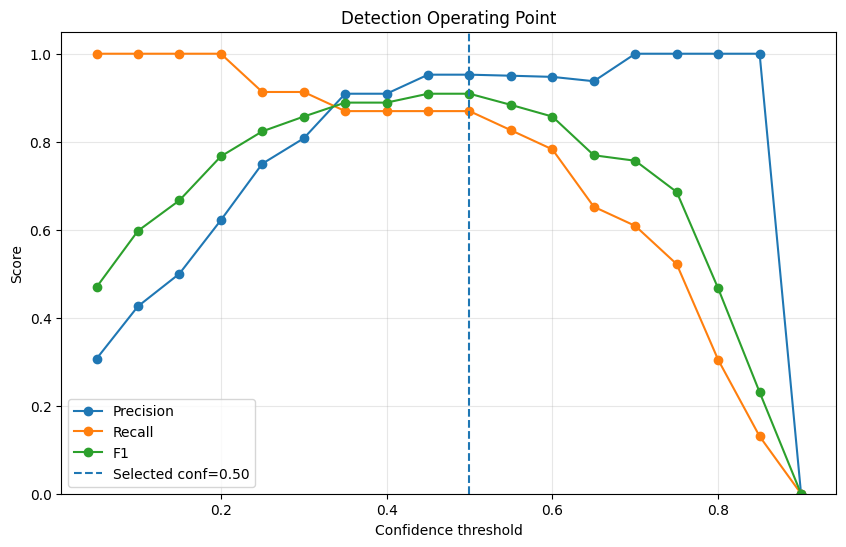

In [ ]:
# ============================================================
# 10. PRECISION / RECALL / F1 VS CONFIDENCE
# ============================================================

plt.figure(figsize=(10, 6))  # Create plot canvas

plt.plot(threshold_df["confidence_threshold"], threshold_df["precision"], marker="o", label="Precision")  # Precision curve
plt.plot(threshold_df["confidence_threshold"], threshold_df["recall"], marker="o", label="Recall")  # Recall curve
plt.plot(threshold_df["confidence_threshold"], threshold_df["f1"], marker="o", label="F1")  # F1 curve
plt.axvline(FINAL_CONF, linestyle="--", label=f"Selected conf={FINAL_CONF:.2f}")  # Mark selected threshold

plt.xlabel("Confidence threshold")
plt.ylabel("Score")
plt.title("Detection Operating Point")
plt.ylim(0, 1.05)  # Keep metric scale consistent
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Precision / Recall / F1 Plot Result

The plot compares validation precision, recall, and F1 across the full confidence sweep and marks the selected confidence **0.50**.

**Interpretation:**  
Increasing the confidence threshold generally removes weaker detections, which can improve precision but reduce recall. The selected operating point represents the validation-ranked balance, where the recorded validation F1 is **90.91%** rather than simply choosing the threshold with the highest precision.


## 11. Test FP / FN Details at Frozen Threshold


**Use case:** Identify and save the exact false-positive and false-negative detections produced on the test set at the frozen confidence threshold.


In [ ]:
# ============================================================
# 11. TEST FP / FN DETAILS AT FROZEN VALIDATION-SELECTED THRESHOLD
# ============================================================

error_rows = []  # Store all test detection errors

for item in test_prediction_cache.values():

    preds = [
        p for p in item["predictions"]
        if p["confidence"] >= FINAL_CONF
    ]  # Keep predictions above frozen confidence

    match = match_predictions_to_gt(
        item["gt_boxes"],
        preds,
        iou_threshold=IOU_MATCH_THRESHOLD
    )  # Match filtered predictions with ground truth

    for pi, pred in enumerate(preds):
        if pi not in match["matched_pred_indices"]:
            error_rows.append({
                "image": item["image_path"].name,
                "error_type": "FP",
                "confidence": pred["confidence"],
                "box": pred["xyxy"].tolist(),
            })  # Unmatched prediction = false positive

    for gi, gt in enumerate(item["gt_boxes"]):
        if gi not in match["matched_gt_indices"]:
            error_rows.append({
                "image": item["image_path"].name,
                "error_type": "FN",
                "confidence": np.nan,
                "box": gt["xyxy"].tolist(),
            })  # Unmatched ground truth = false negative

errors_df = pd.DataFrame(error_rows)  # Convert errors to table

fp_count = int(
    (errors_df["error_type"] == "FP").sum()
) if len(errors_df) else 0

fn_count = int(
    (errors_df["error_type"] == "FN").sum()
) if len(errors_df) else 0

print("Frozen confidence threshold:", f"{FINAL_CONF:.2f}")
print("Test false positives:", fp_count)
print("Test false negatives:", fn_count)

display(errors_df.head(20))

errors_df.to_csv(
    REPORT_DIR / "test_fp_fn_details_frozen_threshold.csv",
    index=False
)  # Save detailed test errors

Frozen confidence threshold: 0.50
Test false positives: 1
Test false negatives: 11


,image,error_type,confidence,box
0,20230614_151246ll.jpg,FN,NaN,"[1054.0004999999999, 960.0, 1671.0015, 1290.0]"
1,20230620_160204ll.jpg,FN,NaN,"[1507.0004999999999, 736.0, 1612.9995000000001..."
2,20230620_160215ll.jpg,FP,0.867517,"[1296.86279296875, 949.6193237304688, 1457.816..."
3,20230620_160215ll.jpg,FN,NaN,"[1284.0000000000002, 924.9999999999999, 1497.0..."
4,20230620_160339ll.jpg,FN,NaN,"[2806.0005, 203.0, 3000.0015000000003, 299.0]"
5,20230620_160454ll.jpg,FN,NaN,"[682.9995, 266.99999999999994, 740.99849999999..."
6,20230620_160735ll.jpg,FN,NaN,"[1222.9995, 1551.0000000000002, 1805.998500000..."
7,20230620_160946ll.jpg,FN,NaN,"[1819.9995, 587.0, 1856.9984999999997, 615.0]"
8,20230620_160946ll.jpg,FN,NaN,"[2044.9995000000001, 569.0, 2063.9985, 583.0]"
9,20230620_160946ll.jpg,FN,NaN,"[2167.0005, 529.0, 2202.0015000000003, 555.0]"


### Test FP / FN Result

- **Frozen confidence threshold:** 0.50
- **False positives:** **1**
- **False negatives:** **11**

**Result:** The test error manifest contains **12 detector errors** at the frozen operating point.

**Interpretation:**  
The detector's main test-set weakness is missed detections rather than false alarms. This is consistent with the high **93.33% precision** but lower **56.00% recall** measured at the same threshold.


## 12. Visualize FP / FN Examples


**Use case:** Visualize representative false-positive and false-negative boxes so the remaining detector errors can be inspected qualitatively.


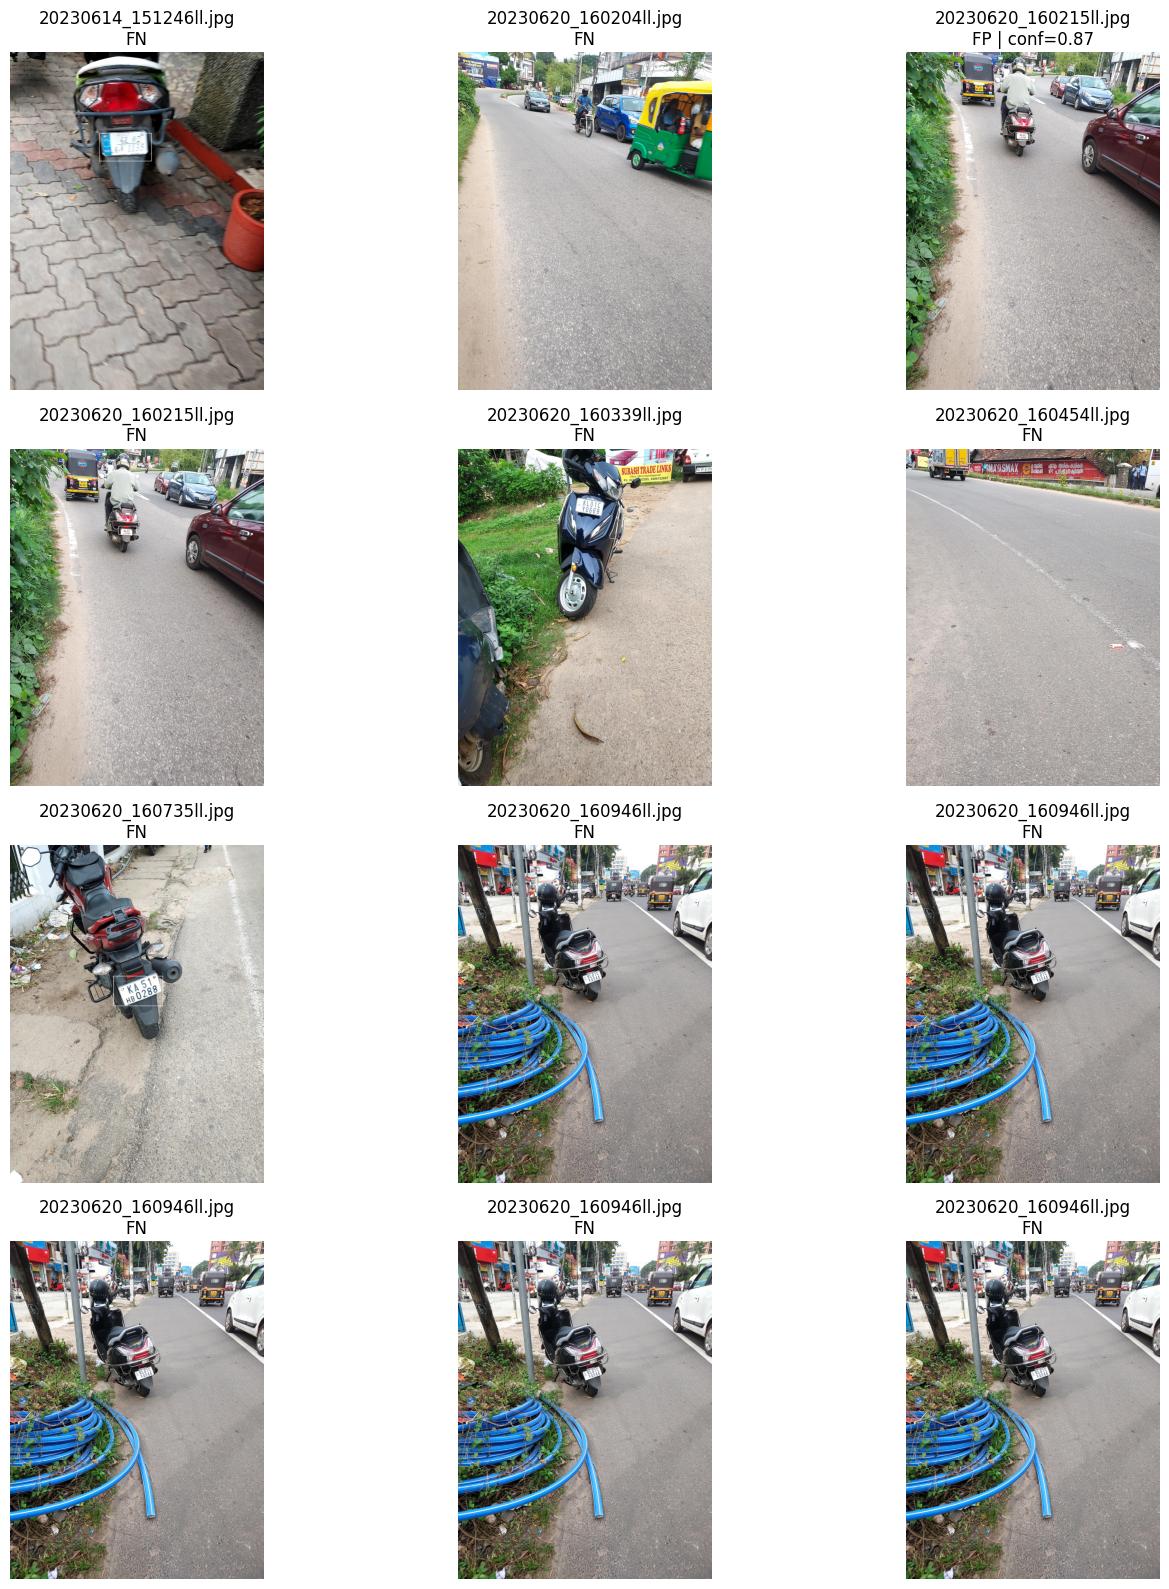

In [ ]:
# ============================================================
# 12. VISUALIZE FP / FN EXAMPLES
# ============================================================

if len(errors_df) == 0:
    print("✅ No FP/FN examples at selected threshold.")  # No test errors to visualize
else:
    sample_errors = errors_df.head(min(12, len(errors_df)))  # Show up to 12 errors
    cols = 3
    rows = math.ceil(len(sample_errors) / cols)  # Calculate subplot rows

    plt.figure(figsize=(15, rows * 4))  # Create visualization canvas

    for idx, (_, err) in enumerate(sample_errors.iterrows(), start=1):
        image_path = TEST_IMG_DIR / err["image"]  # Locate test image
        image = cv2.imread(str(image_path))
        if image is None:
            continue

        x1, y1, x2, y2 = map(int, err["box"])  # Error bounding-box coordinates

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 255, 255), 3)  # Draw error box

        plt.subplot(rows, cols, idx)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB

        title = err["error_type"]
        if err["error_type"] == "FP":
            title += f" | conf={err['confidence']:.2f}"  # Show confidence for FP

        plt.title(f"{err['image']}\n{title}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### FP / FN Visualization Result

**Result:** The notebook visualizes the first **12** recorded test errors using their stored bounding boxes.

**Interpretation:**  
The visual panel makes the numerical error counts inspectable at image level. It helps distinguish missed plates (FN) from the single false-positive detection and provides qualitative evidence for why test recall is lower than validation recall.


## 13. Detector Inference-Time Verification

This checks the project's YOLO <50 ms/image target using Ultralytics-reported inference time.


**Use case:** Verify the final detector's per-image inference speed on the Tesla T4 and assess the project's <50 ms/image target.


In [ ]:
# ============================================================
# 13. FINAL GPU INFERENCE-TIME VERIFICATION
# ============================================================

assert torch.cuda.is_available(), (
    "GPU is not enabled. Switch Colab runtime to T4 GPU."
)  # Require GPU for final timing test

DEVICE = 0
GPU_NAME = torch.cuda.get_device_name(0)  # Get active GPU name

print("GPU:", GPU_NAME)

# Warm-up
warmup_image = str(test_images[0])

for _ in range(3):
    _ = model.predict(
        source=warmup_image,
        conf=FINAL_CONF,
        imgsz=832,
        device=DEVICE,
        verbose=False,
    )  # Warm up GPU/model before timing

torch.cuda.synchronize()  # Wait for queued GPU work to finish

speed_rows = []

for image_path in test_images:

    result = model.predict(
        source=str(image_path),
        conf=FINAL_CONF,
        imgsz=832,
        device=DEVICE,
        verbose=False,
    )[0]  # Run final inference on each test image

    speed = result.speed or {}  # Ultralytics timing dictionary

    speed_rows.append({
        "image": image_path.name,
        "preprocess_ms": float(
            speed.get("preprocess", np.nan)
        ),
        "inference_ms": float(
            speed.get("inference", np.nan)
        ),
        "postprocess_ms": float(
            speed.get("postprocess", np.nan)
        ),
    })  # Store per-image timing

speed_df = pd.DataFrame(speed_rows)  # Build timing table

display(
    speed_df.style.format({
        "preprocess_ms": "{:.2f}",
        "inference_ms": "{:.2f}",
        "postprocess_ms": "{:.2f}",
    })
)

MEAN_INFERENCE_MS = float(
    speed_df["inference_ms"].mean()
)  # Average inference time

MEDIAN_INFERENCE_MS = float(
    speed_df["inference_ms"].median()
)  # Median inference time

print()
print("FINAL YOLO SPEED")
print("----------------")
print("Hardware:", GPU_NAME)
print("Mean inference:", f"{MEAN_INFERENCE_MS:.2f} ms/image")
print("Median inference:", f"{MEDIAN_INFERENCE_MS:.2f} ms/image")
print(
    "Project <50 ms target:",
    "ACHIEVED"
    if MEAN_INFERENCE_MS < 50
    else "NOT ACHIEVED"
)

speed_df.to_csv(
    REPORT_DIR / "detector_inference_time.csv",
    index=False
)  # Save timing report

GPU: Tesla T4


,image,preprocess_ms,inference_ms,postprocess_ms
0,20230614_151238ll.jpg,4.63,19.74,0.54
1,20230614_151246ll.jpg,3.95,19.68,0.45
2,20230620_160118ll.jpg,3.99,19.71,0.51
3,20230620_160204ll.jpg,3.84,19.78,0.52
4,20230620_160215ll.jpg,4.12,19.71,0.52
5,20230620_160337ll.jpg,3.70,19.68,0.48
6,20230620_160339ll.jpg,3.79,19.78,0.52
7,20230620_160454ll.jpg,3.75,19.66,0.45
8,20230620_160735ll.jpg,4.00,19.79,0.41
9,20230620_160946ll.jpg,3.71,19.70,0.55



FINAL YOLO SPEED
----------------
Hardware: Tesla T4
Mean inference: 19.73 ms/image
Median inference: 19.71 ms/image
Project <50 ms target: ACHIEVED


### Detector Inference-Time Result

- **Hardware:** Tesla T4
- **Mean inference time:** **19.73 ms/image**
- **Median inference time:** **19.71 ms/image**
- **Project target:** <50 ms/image
- **Assessment:** ✅ **ACHIEVED**

**Interpretation:**  
The frozen detector comfortably meets the project inference-speed requirement on the tested Tesla T4 hardware. The reported value is YOLO inference time per image and should be interpreted for this hardware/runtime configuration.


## 14. Final Detector Conclusion


**Use case:** Generate a reproducible final detector conclusion directly from the frozen validation, test, operating-point, and speed metrics.


In [ ]:
# ============================================================
# 14. FINAL DETECTOR CONCLUSION
# ============================================================

val_row = detector_metrics[
    detector_metrics["split"] == "validation"
].iloc[0]  # Get validation metrics row

test_row = detector_metrics[
    detector_metrics["split"] == "test"
].iloc[0]  # Get untouched test metrics row

final_lines = [
    "FINAL DETECTOR EVALUATION CONCLUSION",
    "------------------------------------",
    "",
    "Selected model: models/best.pt",
    "",
    "Validation metrics:",
    f"- Precision: {float(val_row['precision']):.2%}",
    f"- Recall: {float(val_row['recall']):.2%}",
    f"- mAP@50: {float(val_row['mAP50']):.2%}",
    f"- mAP@50-95: {float(val_row['mAP50_95']):.2%}",
    "",
    "Untouched test metrics:",
    f"- Precision: {float(test_row['precision']):.2%}",
    f"- Recall: {float(test_row['recall']):.2%}",
    f"- mAP@50: {float(test_row['mAP50']):.2%}",
    f"- mAP@50-95: {float(test_row['mAP50_95']):.2%}",
    "",
    "Operating-point selection:",
    "- Confidence threshold was selected on VALIDATION only.",
    f"- Selected confidence threshold: {FINAL_CONF:.2f}",
    f"- Validation F1 at selected threshold: {VAL_OP_F1:.2%}",
    "",
    "Frozen threshold applied once to TEST:",
    f"- TP: {FINAL_TP}",
    f"- FP: {FINAL_FP}",
    f"- FN: {FINAL_FN}",
    f"- Precision: {FINAL_PRECISION:.2%}",
    f"- Recall: {FINAL_RECALL:.2%}",
    f"- F1: {FINAL_F1:.2%}",
    f"- Mean matched IoU: {FINAL_MEAN_IOU:.3f}",
    "",
    f"Hardware: {GPU_NAME}",
    f"Mean YOLO inference time: {MEAN_INFERENCE_MS:.2f} ms/image",
    f"Median YOLO inference time: {MEDIAN_INFERENCE_MS:.2f} ms/image",
    "Inference target (<50 ms): "
    + (
        "ACHIEVED"
        if MEAN_INFERENCE_MS < 50
        else "NOT ACHIEVED"
    ),
    "",
    "Interpretation:",
    "- Confidence threshold selection used the validation split only.",
    "- The selected threshold was frozen before test operating-point evaluation.",
    "- TP/FP/FN use IoU >= 0.50 matching.",
    "- mAP and operating-point metrics are reported separately.",
    "- Validation mAP@50 exceeded 95%, but this level was not maintained on unseen test data.",
    "- Test mAP@50 is therefore reported separately and transparently.",
    "- Detector and OCR performance are reported separately.",
]  # Build final detector summary from actual results

final_text = "\n".join(final_lines)  # Combine lines into one report

print(final_text)

FINAL_TXT = (
    REPORT_DIR
    / "FINAL_DETECTOR_CONCLUSION.txt"
)

FINAL_TXT.write_text(final_text)  # Save final detector conclusion

print()
print("✅ Saved:", FINAL_TXT)

FINAL DETECTOR EVALUATION CONCLUSION
------------------------------------

Selected model: models/best.pt

Validation metrics:
- Precision: 99.11%
- Recall: 86.96%
- mAP@50: 96.35%
- mAP@50-95: 52.16%

Untouched test metrics:
- Precision: 93.05%
- Recall: 60.00%
- mAP@50: 68.62%
- mAP@50-95: 38.32%

Operating-point selection:
- Confidence threshold was selected on VALIDATION only.
- Selected confidence threshold: 0.50
- Validation F1 at selected threshold: 90.91%

Frozen threshold applied once to TEST:
- TP: 14
- FP: 1
- FN: 11
- Precision: 93.33%
- Recall: 56.00%
- F1: 70.00%
- Mean matched IoU: 0.786

Hardware: Tesla T4
Mean YOLO inference time: 19.73 ms/image
Median YOLO inference time: 19.71 ms/image
Inference target (<50 ms): ACHIEVED

Interpretation:
- Confidence threshold selection used the validation split only.
- The selected threshold was frozen before test operating-point evaluation.
- TP/FP/FN use IoU >= 0.50 matching.
- mAP and operating-point metrics are reported separate

### Final Detector Evaluation Conclusion

The frozen `models/best.pt` detector achieved:

- **Validation:** 99.11% precision, 86.96% recall, 96.35% mAP@50, 52.16% mAP@50-95.
- **Untouched test:** 93.05% precision, 60.00% recall, 68.62% mAP@50, 38.32% mAP@50-95.
- **Validation-selected confidence:** 0.50.
- **Frozen-threshold test operating point:** 14 TP, 1 FP, 11 FN, 93.33% precision, 56.00% recall, 70.00% F1, mean matched IoU 0.786.
- **Mean inference time:** 19.73 ms/image on Tesla T4 → **<50 ms target achieved**.

**Interpretation:**  
The model is fast and maintains high test precision, but unseen-test recall and mAP are materially lower than validation performance. The notebook therefore reports validation selection, untouched-test generalization, fixed-threshold operating metrics, and speed as separate results rather than combining them into one accuracy claim.


## 15. Export Detector Reports to Google Drive


**Use case:** Copy the final detector reports from temporary Colab storage to Google Drive for permanent project evidence.


In [ ]:
# ============================================================
# 15. EXPORT DETECTOR REPORTS TO GOOGLE DRIVE
# ============================================================

DRIVE_RESULTS = (
    Path("/content/drive/MyDrive")
    / "Number-Plate-Detection-Training-Results"
    / "reports"
    / "detection_operating_point"
)  # Final Google Drive report folder

DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)  # Create folder if needed

for file_path in REPORT_DIR.glob("*"):
    if file_path.is_file():
        shutil.copy2(file_path, DRIVE_RESULTS / file_path.name)  # Copy each detector report

print("✅ Detector reports exported to:")
print(DRIVE_RESULTS)

✅ Detector reports exported to:
/content/drive/MyDrive/Number-Plate-Detection-Training-Results/reports/detection_operating_point


### Export Result

**Result:** ✅ Final detector reports were exported to:

`/content/drive/MyDrive/Number-Plate-Detection-Training-Results/reports/detection_operating_point`

**Interpretation:**  
The Drive export preserves the final validation/test metrics, confidence-threshold sweep, FP/FN details, inference timing, and generated detector conclusion beyond the temporary Colab session.


# Notebook 4 Coverage Checklist

- ✅ Final selected YOLO model
- ✅ Frozen dataset verification
- ✅ Validation metrics
- ✅ Untouched test metrics
- ✅ Confidence-threshold sweep
- ✅ IoU matching
- ✅ TP / FP / FN
- ✅ Precision / Recall / F1
- ✅ Selected operating confidence
- ✅ FP/FN inspection
- ✅ Inference-time verification
- ✅ Final detector conclusion
- ✅ Drive export